### Setup và khám phá giá trị

1. Import thư viện

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

import warnings
warnings.filterwarnings('ignore')

2. Đọc dữ liệu và chọn thuộc tính

In [ ]:
df = pd.read_csv("../data/processed/clean_dataset.csv")
df.head()

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,2023-07-29 13:00:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,2023-08-13 00:11:00,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,2021-12-09 10:30:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,2023-08-09 19:55:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,2023-08-19 14:55:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8


In [97]:
cols = [
    'weather_condition',
    'lighting_condition',
    'roadway_surface_cond',
    'trafficway_type',
    'intersection_related_i',
    'traffic_control_device',
    'prim_contributory_cause',
    'first_crash_type',
    'crash_hour',
    'crash_day_of_week',
    'most_severe_injury'
]

df_sel = df[cols].copy()

Bao gồm:
- Môi trường
- Hạ tầng giao thông
- Nguyên nhân
- Thời gian
- Mức độ chấn thương (target)

3. Khám phá các giá trị có trong từng thuộc tính

In [98]:
for col in cols:
    print(f"\n{col.upper()}")
    print(df_sel[col].unique())


WEATHER_CONDITION
['CLEAR' 'RAIN' 'SNOW' 'CLOUDY/OVERCAST' 'UNKNOWN' 'FOG/SMOKE/HAZE'
 'BLOWING SNOW' 'FREEZING RAIN/DRIZZLE' 'OTHER' 'SLEET/HAIL'
 'SEVERE CROSS WIND GATE' 'BLOWING SAND, SOIL, DIRT']

LIGHTING_CONDITION
['DAYLIGHT' 'DARKNESS, LIGHTED ROAD' 'DUSK' 'DARKNESS' 'UNKNOWN' 'DAWN']

ROADWAY_SURFACE_COND
['UNKNOWN' 'DRY' 'WET' 'SNOW OR SLUSH' 'ICE' 'OTHER' 'SAND, MUD, DIRT']

TRAFFICWAY_TYPE
['NOT DIVIDED' 'FOUR WAY' 'T-INTERSECTION'
 'DIVIDED - W/MEDIAN (NOT RAISED)' 'OTHER' 'UNKNOWN' 'ONE-WAY' 'RAMP'
 'TRAFFIC ROUTE' 'FIVE POINT, OR MORE' 'DIVIDED - W/MEDIAN BARRIER'
 'ALLEY' 'CENTER TURN LANE' 'L-INTERSECTION' 'DRIVEWAY' 'Y-INTERSECTION'
 'PARKING LOT' 'ROUNDABOUT']

INTERSECTION_RELATED_I
[1 0]

TRAFFIC_CONTROL_DEVICE
['TRAFFIC SIGNAL' 'NO CONTROLS' 'STOP SIGN/FLASHER' 'UNKNOWN' 'OTHER'
 'PEDESTRIAN CROSSING SIGN' 'OTHER WARNING SIGN' 'YIELD'
 'FLASHING CONTROL SIGNAL' 'LANE USE MARKING' 'OTHER REG. SIGN'
 'DELINEATORS' 'SCHOOL ZONE' 'POLICE/FLAGMAN' 'NO PASSING'
 'RR CR

In [99]:
# tần suất xuất hiện của các giá trị trong mỗi cột
for col in cols:
    print(f"\n{col.upper()}")
    print(df_sel[col].value_counts())


WEATHER_CONDITION
weather_condition
CLEAR                       164700
RAIN                         21703
CLOUDY/OVERCAST               7533
SNOW                          6871
UNKNOWN                       6534
OTHER                          627
FREEZING RAIN/DRIZZLE          510
FOG/SMOKE/HAZE                 360
SLEET/HAIL                     308
BLOWING SNOW                   127
SEVERE CROSS WIND GATE          32
BLOWING SAND, SOIL, DIRT         1
Name: count, dtype: int64

LIGHTING_CONDITION
lighting_condition
DAYLIGHT                  134109
DARKNESS, LIGHTED ROAD     53378
DARKNESS                    7436
DUSK                        6323
UNKNOWN                     4336
DAWN                        3724
Name: count, dtype: int64

ROADWAY_SURFACE_COND
roadway_surface_cond
DRY                155905
WET                 32908
UNKNOWN             12509
SNOW OR SLUSH        6203
ICE                  1303
OTHER                 438
SAND, MUD, DIRT        40
Name: count, dtype: int64

TR

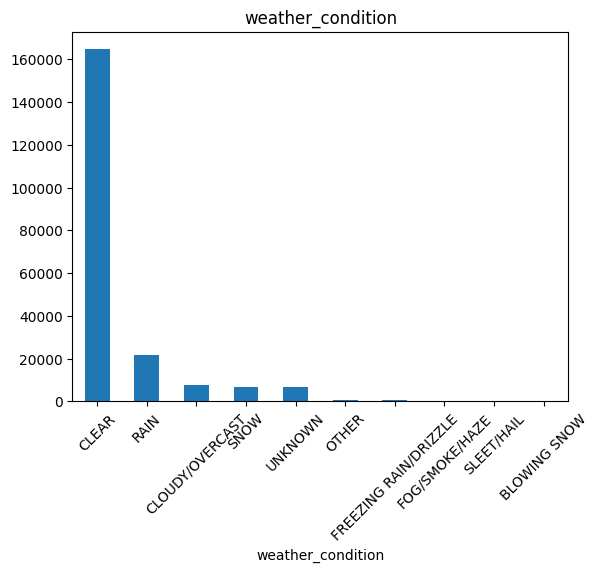

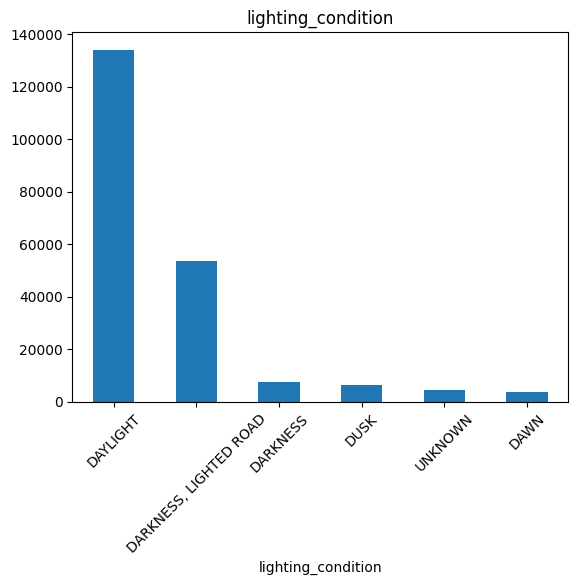

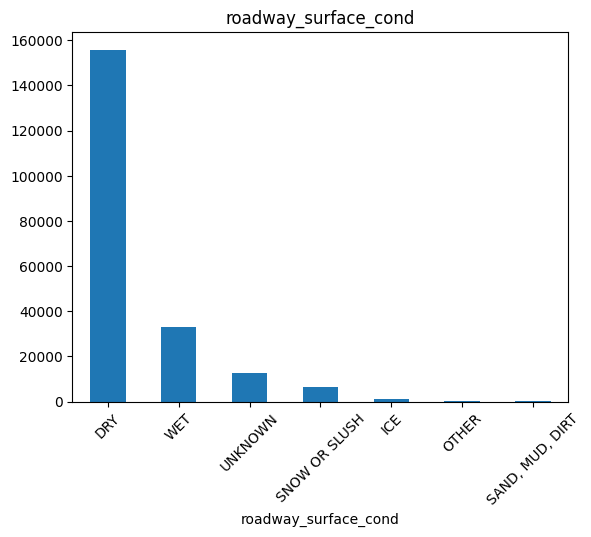

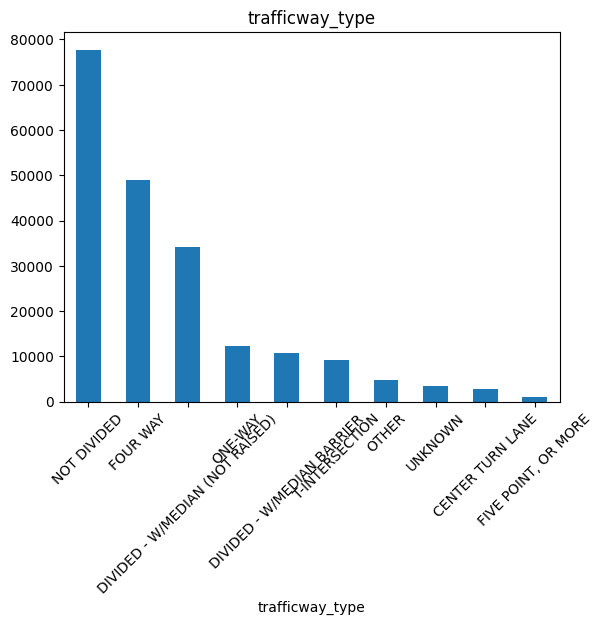

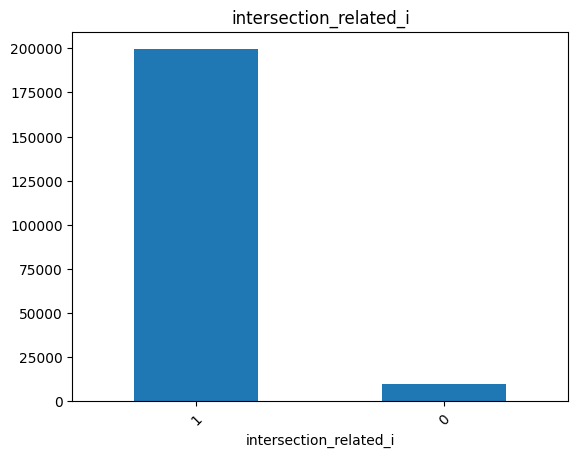

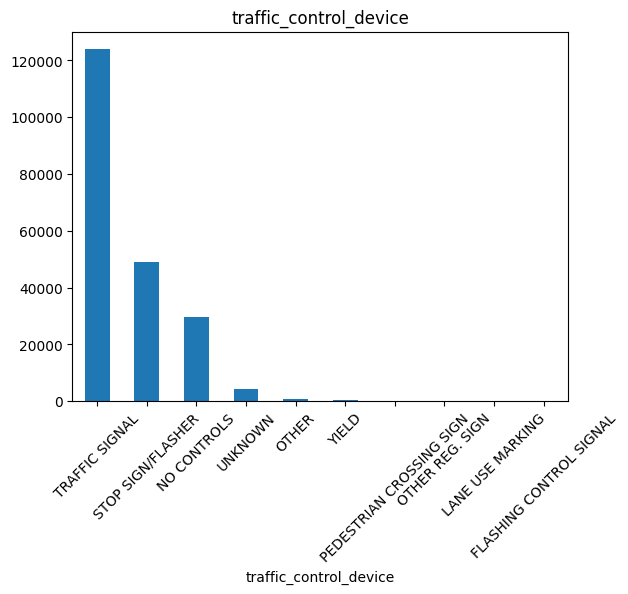

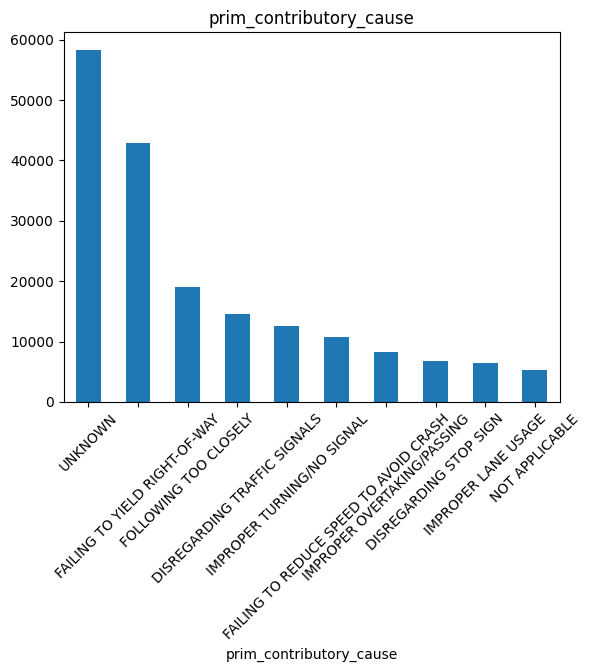

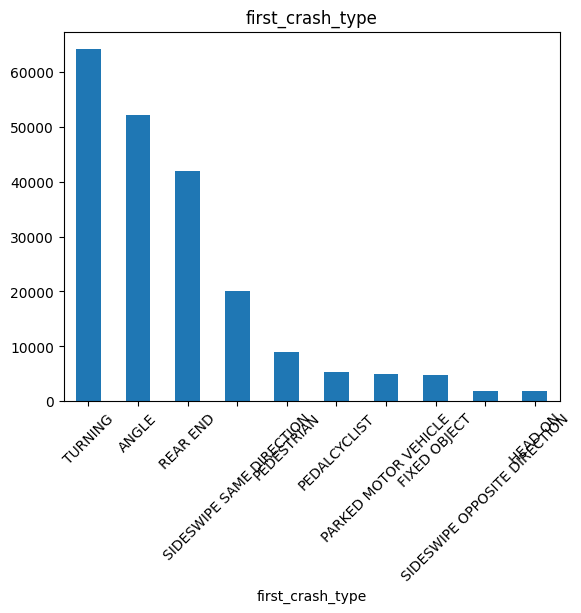

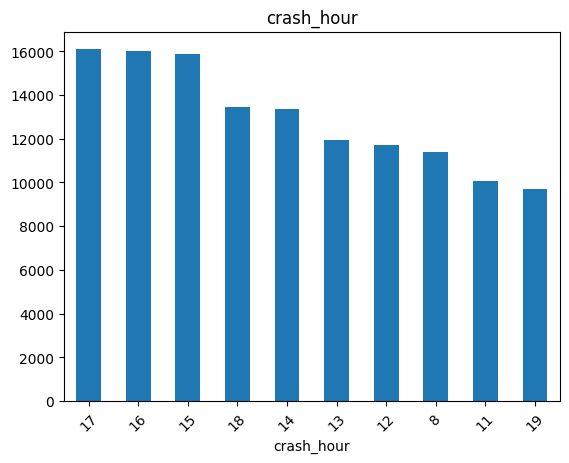

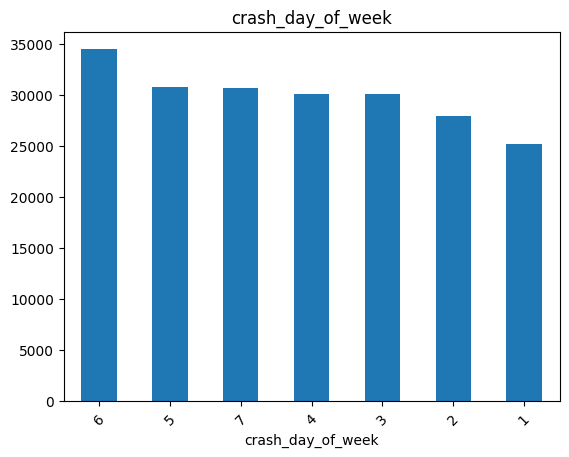

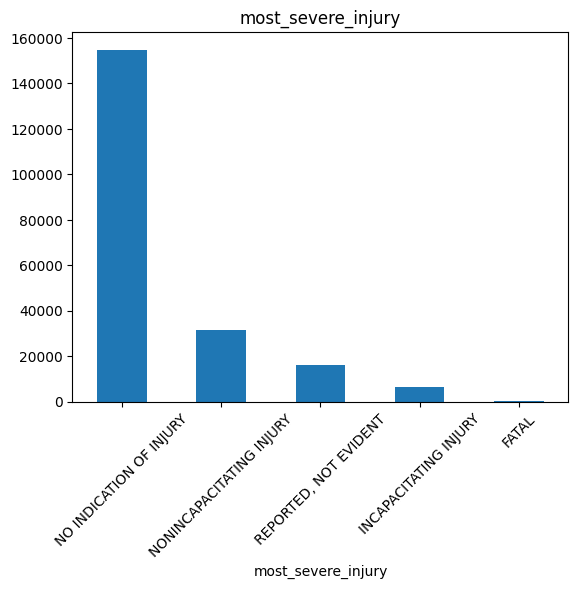

In [100]:
for col in cols:
    plt.figure()
    df_sel[col].value_counts().head(10).plot(kind='bar')
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

In [101]:
threshold = 0.01
# xác định các giá trị hiếm trong mỗi cột
for col in cols:
    freq = df_sel[col].value_counts(normalize=True)
    rare = freq[freq < threshold]
    
    print(f"\n{col.upper()} ")
    print(rare)


WEATHER_CONDITION 
weather_condition
OTHER                       0.002996
FREEZING RAIN/DRIZZLE       0.002437
FOG/SMOKE/HAZE              0.001720
SLEET/HAIL                  0.001472
BLOWING SNOW                0.000607
SEVERE CROSS WIND GATE      0.000153
BLOWING SAND, SOIL, DIRT    0.000005
Name: proportion, dtype: float64

LIGHTING_CONDITION 
Series([], Name: proportion, dtype: float64)

ROADWAY_SURFACE_COND 
roadway_surface_cond
ICE                0.006225
OTHER              0.002093
SAND, MUD, DIRT    0.000191
Name: proportion, dtype: float64

TRAFFICWAY_TYPE 
trafficway_type
FIVE POINT, OR MORE    0.005346
Y-INTERSECTION         0.004577
TRAFFIC ROUTE          0.003707
ALLEY                  0.003540
PARKING LOT            0.002140
RAMP                   0.001792
ROUNDABOUT             0.000712
DRIVEWAY               0.000683
L-INTERSECTION         0.000607
Name: proportion, dtype: float64

INTERSECTION_RELATED_I 
Series([], Name: proportion, dtype: float64)

TRAFFIC_CONTROL_D

### Chuẩn bị dữ liệu (group)

In [102]:
# gom nhóm
def group_weather(x):
    if x == 'CLEAR':
        return 'Clear'
    
    elif x in ['RAIN', 'FREEZING RAIN/DRIZZLE']:
        return 'Rainy'
    
    elif x in ['SNOW', 'SLEET/HAIL', 'BLOWING SNOW']:
        return 'Snow/Ice'
    
    elif x == 'CLOUDY/OVERCAST':
        return 'Cloudy'
    
    elif x == 'FOG/SMOKE/HAZE':
        return 'Low Visibility'
    
    elif x == 'SEVERE CROSS WIND GATE':
        return 'Windy'
    
    elif x in ['OTHER', 'BLOWING SAND, SOIL, DIRT']:
        return 'Other'
    
    else:
        return 'Unknown'

def group_lighting(x):
    if x == 'DAYLIGHT':
        return 'Daylight'
    
    elif x == 'DARKNESS, LIGHTED ROAD':
        return 'Dark Lighted'
    
    elif x == 'DARKNESS':
        return 'Dark'
    
    elif x in ['DUSK', 'DAWN']:
        return 'Low Light'
    
    else:
        return 'Unknown'
    
def group_surface(x):
    if x == 'DRY':
        return 'Dry'
    
    elif x == 'WET':
        return 'Wet'
    
    elif x == 'SNOW OR SLUSH':
        return 'Snow/Slush'
    
    elif x == 'ICE':
        return 'Ice'
    
    elif x in ['OTHER', 'SAND, MUD, DIRT']:
        return 'Other'
    
    else:
        return 'Unknown'
    
def group_trafficway(x):
    if x == 'NOT DIVIDED':
        return 'Undivided Road'
    
    elif x in ['DIVIDED - W/MEDIAN (NOT RAISED)', 'DIVIDED - W/MEDIAN BARRIER']:
        return 'Divided Road'
    
    elif x == 'ONE-WAY':
        return 'One-way'
    
    elif x in ['FOUR WAY', 'T-INTERSECTION', 'Y-INTERSECTION', 'L-INTERSECTION', 'FIVE POINT, OR MORE']:
        return 'Intersection'
    
    elif x == 'ROUNDABOUT':
        return 'Roundabout'
    
    elif x == 'RAMP':
        return 'Ramp'
    
    elif x in ['DRIVEWAY', 'ALLEY', 'PARKING LOT']:
        return 'Access Area'
    
    elif x in ['OTHER', 'TRAFFIC ROUTE']:
        return 'Other'
    
    else:
        return 'Unknown'

def group_control(x):
    if x in ['TRAFFIC SIGNAL', 'FLASHING CONTROL SIGNAL']:
        return 'Signal Control'
    
    elif x in ['STOP SIGN/FLASHER', 'YIELD']:
        return 'Stop/Yield Control'
    
    elif x == 'NO CONTROLS':
        return 'No Control'
    
    elif x == 'POLICE/FLAGMAN':
        return 'Human Control'
    
    elif x in [
        'PEDESTRIAN CROSSING SIGN', 'OTHER WARNING SIGN', 'OTHER REG. SIGN',
        'LANE USE MARKING', 'DELINEATORS', 'NO PASSING',
        'SCHOOL ZONE', 'BICYCLE CROSSING SIGN'
    ]:
        return 'Warning/Guide'
    
    elif x in [
        'RAILROAD CROSSING GATE', 'RR CROSSING SIGN', 'OTHER RAILROAD CROSSING'
    ]:
        return 'Railroad'
    
    elif x == 'OTHER':
        return 'Other'
    
    else:
        return 'Unknown'
    
def group_cause(x):
    if x in [
        'IMPROPER TURNING/NO SIGNAL', 'IMPROPER BACKING',
        'IMPROPER OVERTAKING/PASSING', 'IMPROPER LANE USAGE',
        'DRIVING ON WRONG SIDE/WRONG WAY', 'TURNING RIGHT ON RED'
    ]:
        return 'Driving Behavior'
    
    elif x in [
        'DISREGARDING TRAFFIC SIGNALS', 'DISREGARDING STOP SIGN',
        'DISREGARDING YIELD SIGN', 'DISREGARDING OTHER TRAFFIC SIGNS',
        'DISREGARDING ROAD MARKINGS', 'FAILING TO YIELD RIGHT-OF-WAY'
    ]:
        return 'Traffic Violation'
    
    elif x in [
        'FOLLOWING TOO CLOSELY', 'FAILING TO REDUCE SPEED TO AVOID CRASH',
        'EXCEEDING SAFE SPEED FOR CONDITIONS', 'EXCEEDING AUTHORIZED SPEED LIMIT'
    ]:
        return 'Speed & Distance'
    
    elif 'DISTRACTION' in x or x in ['TEXTING', 'CELL PHONE USE OTHER THAN TEXTING']:
        return 'Distraction'
    
    elif x in [
        'UNDER THE INFLUENCE OF ALCOHOL/DRUGS (USE WHEN ARREST IS EFFECTED)',
        'HAD BEEN DRINKING (USE WHEN ARREST IS NOT MADE)',
        'PHYSICAL CONDITION OF DRIVER'
    ]:
        return 'Impairment'
    
    elif x in [
        'DRIVING SKILLS/KNOWLEDGE/EXPERIENCE',
        'VISION OBSCURED (SIGNS, TREE LIMBS, BUILDINGS, ETC.)'
    ]:
        return 'Skill Issue'
    
    elif x in [
        'WEATHER', 'ANIMAL',
        'EVASIVE ACTION DUE TO ANIMAL, OBJECT, NONMOTORIST'
    ]:
        return 'External Factors'
    
    elif x in [
        'EQUIPMENT - VEHICLE CONDITION',
        'ROAD ENGINEERING/SURFACE/MARKING DEFECTS',
        'ROAD CONSTRUCTION/MAINTENANCE'
    ]:
        return 'Vehicle/Infrastructure'
    
    elif x in ['UNKNOWN', 'NOT APPLICABLE']:
        return 'Unknown'
    
    else:
        return 'Other'
    
def group_crash(x):
    if 'REAR' in x:
        return 'Rear-end'
    
    elif x in ['ANGLE', 'TURNING']:
        return 'Angle/Turning'
    
    elif 'SIDESWIPE' in x:
        return 'Sideswipe'
    
    elif x == 'HEAD ON':
        return 'Head-on'
    
    elif x in ['FIXED OBJECT', 'OTHER OBJECT']:
        return 'Fixed Object'
    
    elif x == 'PARKED MOTOR VEHICLE':
        return 'Parked Vehicle'
    
    elif x in ['PEDESTRIAN', 'PEDALCYCLIST']:
        return 'Vulnerable User'
    
    elif x in ['OVERTURNED', 'OTHER NONCOLLISION']:
        return 'Non-collision'
    
    elif x in ['ANIMAL', 'TRAIN']:
        return 'Other'
    
    else:
        return 'Other'
    
def group_hour(h):
    if 0 <= h <= 5:
        return 'Early Morning'
    elif 6 <= h <= 11:
        return 'Morning'
    elif 12 <= h <= 17:
        return 'Afternoon'
    elif 18 <= h <= 21:
        return 'Evening'
    else:
        return 'Night'
    
def group_day(d):
    if d in [6, 7]:
        return 'Weekend'
    else:
        return 'Weekday'

def group_injury(x):
    if x in ['INCAPACITATING INJURY', 'FATAL']:
        return 'Severe'
    else:
        return 'Non-Severe'

In [103]:
# áp dụng grouping
df['weather_group'] = df['weather_condition'].apply(group_weather)
df['lighting_group'] = df['lighting_condition'].apply(group_lighting)
df['surface_group'] = df['roadway_surface_cond'].apply(group_surface)
df['trafficway_group'] = df['trafficway_type'].apply(group_trafficway)
df['control_group'] = df['traffic_control_device'].apply(group_control)
df['cause_group'] = df['prim_contributory_cause'].apply(group_cause)
df['crash_group'] = df['first_crash_type'].apply(group_crash)
df['hour_group'] = df['crash_hour'].apply(group_hour)
df['day_group'] = df['crash_day_of_week'].apply(group_day)
df['injury_group'] = df['most_severe_injury'].apply(group_injury)

df['intersection_related_i'] = df['intersection_related_i'].map({
    1: 'Intersection',
    0: 'Non-Intersection'
})

df.head()

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,weather_group,lighting_group,surface_group,trafficway_group,control_group,cause_group,crash_group,hour_group,day_group,injury_group
0,2023-07-29 13:00:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,Clear,Daylight,Unknown,Undivided Road,Signal Control,Unknown,Angle/Turning,Afternoon,Weekend,Non-Severe
1,2023-08-13 00:11:00,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,Clear,Dark Lighted,Dry,Intersection,Signal Control,Driving Behavior,Angle/Turning,Early Morning,Weekday,Non-Severe
2,2021-12-09 10:30:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,Clear,Daylight,Dry,Intersection,Signal Control,Speed & Distance,Rear-end,Morning,Weekday,Non-Severe
3,2023-08-09 19:55:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,Clear,Daylight,Dry,Intersection,Signal Control,Unknown,Angle/Turning,Evening,Weekday,Non-Severe
4,2023-08-19 14:55:00,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,Clear,Daylight,Unknown,Intersection,Signal Control,Skill Issue,Rear-end,Afternoon,Weekend,Non-Severe


Việc grouping giúp:
- Tăng support
- Giảm nhiễu
- Luật rõ nghĩa hơn

### Bài toán 1: Khám phá pattern phổ biến trong tai nạn giao thông

In [104]:
cols_bt1 = [
    'weather_group','lighting_group','surface_group',
    'trafficway_group','control_group','cause_group',
    'crash_group','hour_group','day_group','intersection_related_i'
]

def create_transactions(row):
    return {
        f"Weather={row['weather_group']}",
        f"Lighting={row['lighting_group']}",
        f"Surface={row['surface_group']}",
        f"Trafficway={row['trafficway_group']}",
        f"Control={row['control_group']}",
        f"Cause={row['cause_group']}",
        f"Crash={row['crash_group']}",
        f"Hour={row['hour_group']}",
        f"Day={row['day_group']}",
        f"Intersection={row['intersection_related_i']}"
    }
    
transactions_bt1 = df.apply(create_transactions, axis=1)

#print(transactions_bt1[:5])

te = TransactionEncoder()
te_array = te.fit(transactions_bt1).transform(transactions_bt1)
df_encoded_bt1 = pd.DataFrame(te_array, columns=te.columns_)

freq_bt1 = apriori(df_encoded_bt1, min_support=0.02, use_colnames=True)
rules_bt1 = association_rules(freq_bt1, metric="confidence", min_threshold=0.6)

print(f"Tìm thấy {len(rules_bt1)} luật kết hợp với min_support=0.02 và min_confidence=0.6")

Tìm thấy 36975 luật kết hợp với min_support=0.02 và min_confidence=0.6


In [105]:
def min_max_scale(series):
    return (series - series.min()) / (series.max() - series.min())

In [ ]:
rules_bt1_filtered = rules_bt1[
    (rules_bt1['lift'] > 1.5) &
    (rules_bt1['confidence'] > 0.7)
]

rules_bt1_filtered = rules_bt1_filtered[
    rules_bt1_filtered['antecedents'].apply(lambda x: len(x) >= 2)
]

# loại những luật có unknown
def no_unknown(rule):
    items = list(rule['antecedents']) + list(rule['consequents'])
    return not any('Unknown' in item for item in items)

rules_bt1_filtered = rules_bt1_filtered[
    rules_bt1_filtered.apply(no_unknown, axis=1)
]

# kiểm tra và lọc luật hiển nhiên
# định nghĩa các cặp features có tương quan cao (dependent)
dependent_pairs = [
    # cặp Thời tiết và Mặt đường
    ('Weather=Rainy', 'Surface=Wet'), 
    ('Weather=Snow/Ice', 'Surface=Snow/Slush'),
    ('Weather=Snow/Ice', 'Surface=Ice'),
    ('Weather=Clear', 'Surface=Dry'),
    
    # cặp Ánh sáng và Thời gian
    ('Lighting=Daylight', 'Hour=Morning'),
    ('Lighting=Daylight', 'Hour=Afternoon'),
    ('Lighting=Dark Lighted', 'Hour=Early Morning'),
    ('Lighting=Dark Lighted', 'Hour=Night'),
    ('Lighting=Dark', 'Hour=Night'),
    ('Lighting=Dark', 'Hour=Early Morning')
]

def is_trivial_rule(rule, pairs):
    items = list(rule['antecedents']) + list(rule['consequents'])
    
    for feat1, feat2 in pairs:
        if feat1 in items and feat2 in items:
            return True, feat1, feat2
    return False, None, None

# tách biệt luật có cặp features tương quan cao (trivial) và luật không có (clean)
rules_clean = []
rules_redundant = []

for _, rule in rules_bt1_filtered.iterrows():
    is_trivial, feat1, feat2 = is_trivial_rule(rule, dependent_pairs)
    if is_trivial:
        rules_redundant.append((rule, feat1, feat2))
    else:
        rules_clean.append(rule)

if rules_clean:
    rules_clean = pd.DataFrame(rules_clean)
else:
    rules_clean = pd.DataFrame(columns=rules_bt1_filtered.columns)

print(f"QC Trivial Rules: {len(rules_clean)} sạch / {len(rules_redundant)} redundant")

rules_clean['conf_norm'] = min_max_scale(rules_clean['confidence'])
rules_clean['lift_norm'] = min_max_scale(rules_clean['lift'])
rules_clean['supp_norm'] = min_max_scale(rules_clean['support'])

rules_clean['score'] = (
    rules_clean['conf_norm'] * 0.5 +
    rules_clean['lift_norm'] * 0.3 +
    rules_clean['supp_norm'] * 0.2
)

# phân loại luật theo chủ đề
# điều kiện môi trường
env_cols = ['Weather=', 'Lighting=', 'Surface=']
# hành vi/va chạm
behavior_cols = ['Cause=', 'Crash=']
# giao thông
traffic_cols = ['Trafficway=', 'Control=', 'Intersection=']

def check_themes(rule):
    items = list(rule['antecedents']) + list(rule['consequents'])
    
    has_env = any(any(col in item for col in env_cols) for item in items)
    has_behavior = any(any(col in item for col in behavior_cols) for item in items)
    has_traffic = any(any(col in item for col in traffic_cols) for item in items)
    
    return has_env, has_behavior, has_traffic

env_rules = rules_clean[
    rules_clean.apply(lambda r: check_themes(r) == (True, False, False), axis=1)
]

behavior_rules = rules_clean[
    rules_clean.apply(lambda r: check_themes(r) == (False, True, False), axis=1)
]

traffic_rules = rules_clean[
    rules_clean.apply(lambda r: check_themes(r) == (False, False, True), axis=1)
]

mixed_rules = rules_clean[
    rules_clean.apply(lambda r: sum(check_themes(r)) >= 2, axis=1)
]

print(f"Số luật môi trường: {len(env_rules)}")
print(f"Số luật hành vi/va chạm: {len(behavior_rules)}")
print(f"Số luật giao thông: {len(traffic_rules)}")
print(f"Số luật kết hợp: {len(mixed_rules)}")

QC Trivial Rules: 483 sạch / 2241 redundant
Số luật môi trường: 0
Số luật hành vi/va chạm: 6
Số luật giao thông: 0
Số luật kết hợp: 477


Nhận xét: Từ tổng số 36975 luật ban đầu, sau khi áp dụng các bước lọc về độ tin cậy, độ nâng (lift), loại bỏ nhiễu và kiểm soát các luật hiển nhiên, số lượng luật giảm xuống còn 483 luật, tương đương khoảng 1.3%. Điều này cho thấy phần lớn các luật ban đầu không mang nhiều giá trị phân tích và việc áp dụng các tiêu chí lọc là cần thiết để giữ lại các pattern có ý nghĩa

### BT1 Visualization - Top Patterns

In [128]:
def format_rules(df):
    df = df.copy()
    
    df['antecedents'] = df['antecedents'].apply(lambda x: '\n'.join(list(x)))
    df['consequents'] = df['consequents'].apply(lambda x: '\n'.join(list(x)))
    
    pd.set_option('display.max_colwidth', None)

    cols_to_show = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
    if 'Loại kết hợp' in df.columns:
        cols_to_show.insert(2, 'Loại kết hợp')

    return df[cols_to_show].style.format({
        'support': '{:.4f}',
        'confidence': '{:.2f}',
        'lift': '{:.2f}'
    })

top_env = env_rules.sort_values(by='score', ascending=False).head(10)
top_behavior = behavior_rules.sort_values(by='score', ascending=False).head(10)
top_traffic = traffic_rules.sort_values(by='score', ascending=False).head(10)
top_mixed = mixed_rules.sort_values(by='score', ascending=False).head(10)

In [108]:
print("Top 10 Luật về Điều kiện Môi trường:")
top_env_raw = top_env.copy()
format_rules(top_env)

Top 10 Luật về Điều kiện Môi trường:


,antecedents,consequents,support,confidence,lift


In [109]:
def format_rule_string(row):
    ant = '{' + ', '.join(list(row['antecedents'])) + '}'
    con = '{' + ', '.join(list(row['consequents'])) + '}'
    return f"{ant} -> {con}"

if len(top_env_raw) == 0:
    print("Không có luật nào về điều kiện môi trường sau khi lọc.")
else:
    top_env_raw['rule'] = top_env_raw.apply(format_rule_string, axis=1)

    plt.figure(figsize=(10,6))
    ax = sns.barplot(x='score', y='rule', data=top_env_raw, palette='Greens_d')
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.2f}', 
                    (p.get_width() - 0.05, p.get_y() + p.get_height()/2), 
                    ha='center', va='center', color='white', fontweight='bold')
    ax.set_title('Top 10 Luật về Điều kiện Môi trường')
    ax.set_xlabel('Score')
    ax.set_ylabel('Luật')
    plt.tight_layout()
    plt.show()

Không có luật nào về điều kiện môi trường sau khi lọc.


In [110]:
print("Top 10 Luật về Hành vi/Va chạm:")
top_behavior_raw = top_behavior.copy()
format_rules(top_behavior)

Top 10 Luật về Hành vi/Va chạm:


,antecedents,consequents,support,confidence,lift
421,Cause=Traffic Violation Hour=Early Morning,Crash=Angle/Turning,0.0269,0.89,1.60
324,Cause=Speed & Distance Hour=Afternoon,Crash=Rear-end,0.0461,0.75,3.58
321,Day=Weekday Cause=Speed & Distance,Crash=Rear-end,0.0727,0.72,3.45
2299,Day=Weekday Cause=Speed & Distance Hour=Afternoon,Crash=Rear-end,0.0320,0.75,3.59
325,Hour=Morning Cause=Speed & Distance,Crash=Rear-end,0.0273,0.74,3.50
323,Cause=Speed & Distance Day=Weekend,Crash=Rear-end,0.0331,0.72,3.43


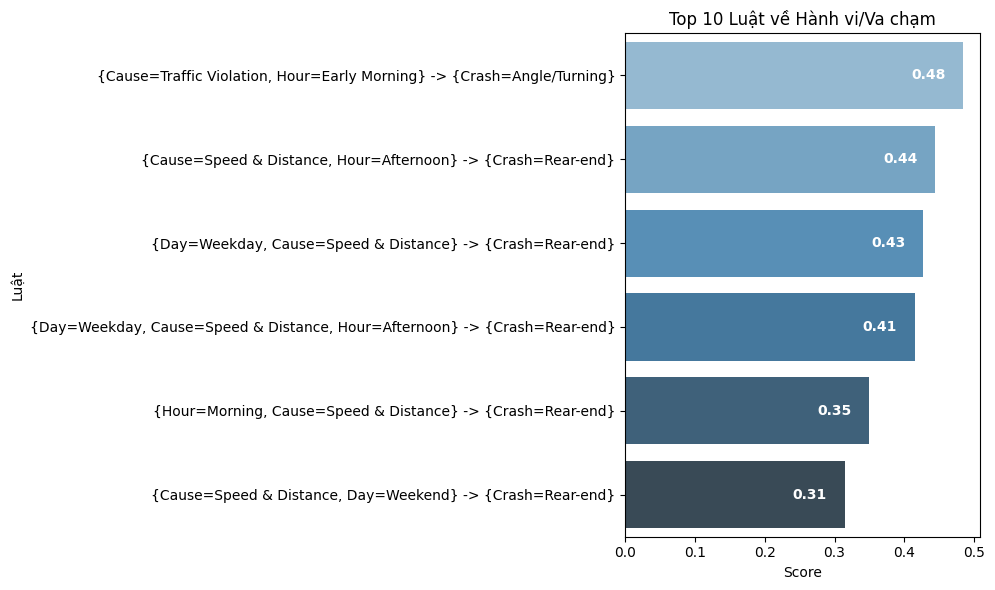

In [111]:
if len(top_behavior_raw) == 0:
    print("Không có luật nào về hành vi/va chạm sau khi lọc.")
else:
    top_behavior_raw['rule'] = top_behavior_raw.apply(format_rule_string, axis=1)

    plt.figure(figsize=(10,6))
    ax = sns.barplot(x='score', y='rule', data=top_behavior_raw, palette='Blues_d')
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.2f}', 
                    (p.get_width() - 0.05, p.get_y() + p.get_height()/2), 
                    ha='center', va='center', color='white', fontweight='bold')
    ax.set_title('Top 10 Luật về Hành vi/Va chạm')
    ax.set_xlabel('Score')
    ax.set_ylabel('Luật')
    plt.tight_layout()
    plt.show()

In [112]:
print("Top 10 Luật về Giao thông:")
top_traffic_raw = top_traffic.copy()
format_rules(top_traffic)

Top 10 Luật về Giao thông:


,antecedents,consequents,support,confidence,lift


In [113]:
if len(top_traffic_raw) == 0:
    print("Không có luật nào về giao thông đạt tiêu chí lọc.")
else:
    top_traffic_raw['rule'] = top_traffic_raw.apply(format_rule_string, axis=1)

    plt.figure(figsize=(10,6))
    ax = sns.barplot(x='score', y='rule', data=top_traffic_raw, palette='Reds_d')
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.2f}', 
                    (p.get_width() - 0.05, p.get_y() + p.get_height()/2), 
                    ha='center', va='center', color='white', fontweight='bold')
    ax.set_title('Top 10 Luật về Giao thông')
    ax.set_xlabel('Score')
    ax.set_ylabel('Luật')
    plt.tight_layout()
    plt.show()

Không có luật nào về giao thông đạt tiêu chí lọc.


Nhận xét (theo từng nhóm):
- Đối với nhóm Môi trường và Giao thông: Tuy trả về kết quả là 0 luật nhưng không phải là lỗi. Vì ban đầu, trước khi lọc các luật hiển nhiên (như Weather=Clean -> Surface=Dry, ...) thì tìm thấy nhiều luật về Môi trường với độ tin cậy cao (> 80%) nhưng nó lại không mang ý nghĩa thực tế, trời quang thì đường khô là điều hết sức hiển nhiên. Còn nhóm Giao thông từ đầu đã hiếm sẵn. Cho nên việc áp dụng loại bỏ các "nhiễu" thuộc tính là cần thiết, kết quả 0 luật cho thấy các yếu tố môi trường hay hạ tầng giao thông không gây ra các vụ tai nạn phổ biến nếu không đi kèm với lỗi hành vi của con người.
- Nhóm Hành vi/Va chạm: Tìm thấy được 6 luật, con số không cao nhưng cũng đủ cho thấy không cần sự tác động của ngoại cảnh thì vẫn có khả năng cao gây tai nạn. Tổ hợp {Cause=Traffic Violation, Hour=Early Morning} -> {Crash=Angle/Turning} đạt Score cao nhất ($0.48$) trong nhóm. Điều này cho thấy vào thời điểm sáng sớm, các hành vi vi phạm giao thông có xu hướng dẫn đến các va chạm dạng góc (Angle/Turning), phản ánh đặc trưng của các tình huống giao cắt tại nút giao, nơi mà việc không tuân thủ tín hiệu hoặc quyền ưu tiên dễ dẫn đến xung đột hướng di chuyển.

In [131]:
def get_combination_label(rule):
    has_env, has_beh, has_tra = check_themes(rule)
    
    themes = []
    if has_env: themes.append("Môi trường")
    if has_beh: themes.append("Hành vi")
    if has_tra: themes.append("Giao thông")
    
    return " + ".join(themes)

print("Top 10 Luật Kết hợp:")

top_mixed_raw = top_mixed.copy()

top_mixed['Loại kết hợp'] = top_mixed.apply(get_combination_label, axis=1)
format_rules(top_mixed)

Top 10 Luật Kết hợp:


,antecedents,consequents,Loại kết hợp,support,confidence,lift
2712,Intersection=Intersection Cause=Traffic Violation Control=Stop/Yield Control,Crash=Angle/Turning,Hành vi + Giao thông,0.0986,0.89,1.60
411,Cause=Traffic Violation Control=Stop/Yield Control,Crash=Angle/Turning,Hành vi + Giao thông,0.0998,0.89,1.60
2713,Cause=Traffic Violation Control=Stop/Yield Control,Crash=Angle/Turning Intersection=Intersection,Hành vi + Giao thông,0.0986,0.88,1.62
9300,Weather=Clear Intersection=Intersection Cause=Traffic Violation Control=Stop/Yield Control,Crash=Angle/Turning,Môi trường + Hành vi + Giao thông,0.0788,0.89,1.59
2726,Weather=Clear Cause=Traffic Violation Control=Stop/Yield Control,Crash=Angle/Turning,Môi trường + Hành vi + Giao thông,0.0797,0.88,1.59
9284,Surface=Dry Intersection=Intersection Cause=Traffic Violation Control=Stop/Yield Control,Crash=Angle/Turning,Môi trường + Hành vi + Giao thông,0.0761,0.89,1.59
2720,Surface=Dry Cause=Traffic Violation Control=Stop/Yield Control,Crash=Angle/Turning,Môi trường + Hành vi + Giao thông,0.0770,0.89,1.59
8130,Control=Signal Control Lighting=Daylight Cause=Speed & Distance Trafficway=Undivided Road,Crash=Rear-end,Môi trường + Hành vi + Giao thông,0.0226,0.82,3.91
2900,Intersection=Intersection Cause=Traffic Violation Trafficway=Intersection,Crash=Angle/Turning,Hành vi + Giao thông,0.0970,0.86,1.55
9278,Lighting=Daylight Intersection=Intersection Cause=Traffic Violation Control=Stop/Yield Control,Crash=Angle/Turning,Môi trường + Hành vi + Giao thông,0.0673,0.89,1.60


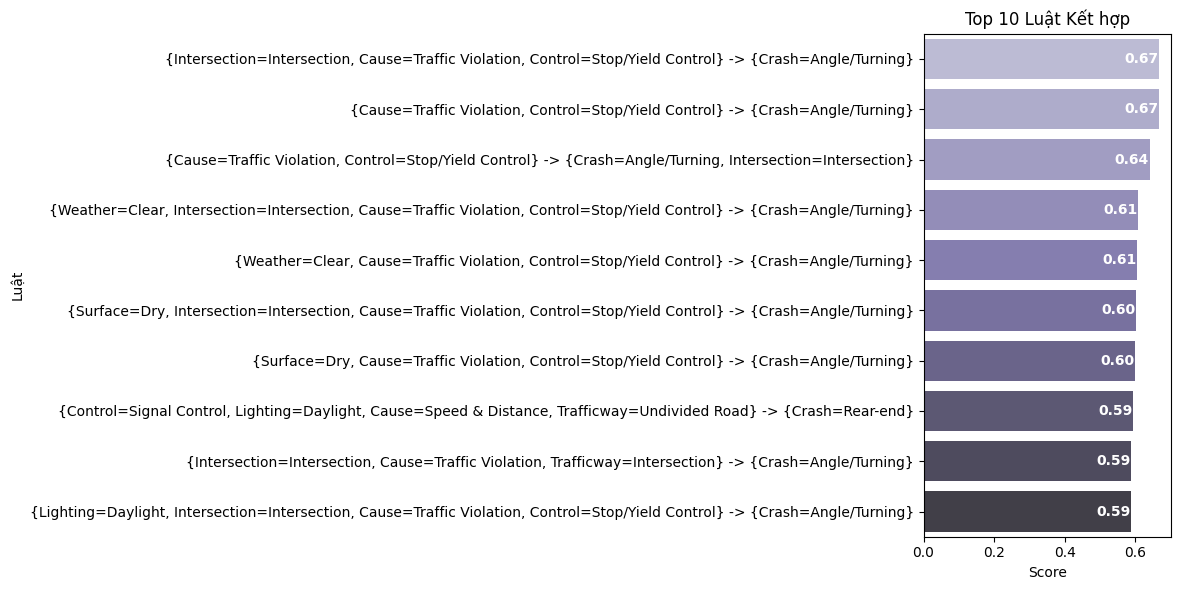

In [115]:
if len(top_mixed_raw) == 0:
    print("Không có luật kết hợp nào sau khi lọc.")
else:
    top_mixed_raw['rule'] = top_mixed_raw.apply(format_rule_string, axis=1)

    plt.figure(figsize=(12,6))
    ax = sns.barplot(x='score', y='rule', data=top_mixed_raw, palette='Purples_d')
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.2f}', 
                    (p.get_width() - 0.05, p.get_y() + p.get_height()/2), 
                    ha='center', va='center', color='white', fontweight='bold')
    ax.set_title('Top 10 Luật Kết hợp')
    ax.set_xlabel('Score')
    ax.set_ylabel('Luật')
    plt.tight_layout()
    plt.show()

Nhận xét (nhóm kết hợp):

Việc tìm thấy 477 luật kết hợp là minh chứng cho việc tai nạn là kết hợp của nhiều yếu tố thay vì đơn lẻ:
- Hiệu suất vượt trội: Các luật kết hợp đạt mức Score lên tới 0.67, cao hơn hẳn so với nhóm Hành vi đơn lẻ.
- Kịch bản nguy hiểm nhất: Sự kết hợp giữa hạ tầng (Intersection, Stop/Yield Control) và hành vi (Traffic Violation) dẫn đến va chạm Angle/Turning chiếm đa số các vị trí dẫn đầu.
- Sự giao thoa Môi trường: Nhóm này bắt đầu xuất hiện các yếu tố Môi trường "sạch" (đã qua lọc) như Weather=Clear, Surface=Dry, và Lighting=Daylight phối hợp cùng lỗi tốc độ và hạ tầng.

Insight: Tai nạn phổ biến nhất không xảy ra khi trời mưa bão, mà xảy ra tại các nút giao có kiểm soát (Intersection with Control) trong điều kiện thời tiết đẹp, khi tài xế chủ quan vi phạm luật hoặc không giữ khoảng cách an toàn.

Summary Statistics - Bài toán 1

In [133]:
print("SUMMARY STATISTICS - BT1 Common Patterns")

def print_rule_summary(rules_df, name):
    if len(rules_df) == 0:
        print(f"\n{name}")
        print(f"  Không có luật")
        return
    
    print(f"\n{name}")
    print(f"  Số luật: {len(rules_df)}")
    print(f"  Avg Confidence: {rules_df['confidence'].mean():.3f}")
    print(f"  Avg Lift: {rules_df['lift'].mean():.3f}")
    print(f"  Avg Support: {rules_df['support'].mean():.4f}")
    print(f"  Max Lift: {rules_df['lift'].max():.3f}")
    print(f"  Min Lift: {rules_df['lift'].min():.3f}")

print_rule_summary(env_rules, "Environmental Patterns")
print_rule_summary(behavior_rules, "Behavioral Patterns")
print_rule_summary(traffic_rules, "Traffic Patterns")
print_rule_summary(mixed_rules, "Mixed Patterns")

# Tổng hợp
print(f"\nTổng hợp BT1:")
print(f"  Tổng luật phát hiện: {len(rules_bt1)}")
print(f"  Tổng luật sau lọc: {len(rules_clean)}")
print(f"  Luật đã phân loại: {len(env_rules) + len(behavior_rules) + len(traffic_rules) + len(mixed_rules)}")

SUMMARY STATISTICS - BT1 Common Patterns

Environmental Patterns
  Không có luật

Behavioral Patterns
  Số luật: 6
  Avg Confidence: 0.763
  Avg Lift: 3.191
  Avg Support: 0.0397
  Max Lift: 3.590
  Min Lift: 1.598

Traffic Patterns
  Không có luật

Mixed Patterns
  Số luật: 477
  Avg Confidence: 0.809
  Avg Lift: 2.291
  Avg Support: 0.0372
  Max Lift: 3.973
  Min Lift: 1.500

Tổng hợp BT1:
  Tổng luật phát hiện: 36975
  Tổng luật sau lọc: 483
  Luật đã phân loại: 483


Nhận xét:
- Nhóm Môi trường và Giao thông: Không có luật nào được giữ lại trong hai nhóm này sau quá trình lọc. Kết quả này phản ánh rằng các yếu tố môi trường và hạ tầng, khi xét độc lập, không tạo thành các pattern tai nạn đủ mạnh về mặt thống kê. Đồng thời, các mối quan hệ hiển nhiên (ví dụ giữa thời tiết và tình trạng mặt đường) đã bị loại bỏ, góp phần làm giảm đáng kể số lượng luật trong nhóm này.
- Nhóm Hành vi/Va chạm: Nhóm này chỉ bao gồm 6 luật, tuy số lượng hạn chế nhưng có chất lượng cao. Giá trị confidence trung bình đạt 0.763 và lift trung bình đạt 3.191, cao hơn đáng kể so với nhóm kết hợp. Điều này cho thấy các luật trong nhóm hành vi có mức độ liên kết mạnh, phản ánh vai trò trực tiếp của hành vi người lái trong việc hình thành tai nạn. Tuy nhiên, support trung bình (0.0397) ở mức trung bình, cho thấy các pattern này không phải là phổ biến nhất, mà mang tính đặc trưng cho một số tình huống cụ thể.
- Nhóm Kết hợp: Đây là nhóm chiếm ưu thế với 477 luật, chiếm gần như toàn bộ tập luật sau lọc. Nhóm này có confidence trung bình cao (0.809) và lift trung bình đạt 2.291, cho thấy các pattern vừa có độ tin cậy tốt vừa có mối liên hệ đáng kể giữa các yếu tố. Mặc dù lift trung bình thấp hơn nhóm hành vi, nhưng nhóm kết hợp lại có:
    + Số lượng lớn hơn
    + Độ bao phủ cao hơn (support trung bình 0.0372)
    + Đáng chú ý, giá trị lift tối đa đạt 3.973, cho thấy vẫn tồn tại những tổ hợp yếu tố có mối liên hệ rất mạnh, đặc biệt khi nhiều yếu tố cùng tác động

### Bài toán 2: Phân tích các yếu tố dẫn đến chấn thương nghiêm trọng

In [117]:
cols_bt2 = cols_bt1 + ['injury_group']

def create_transactions_bt2(row):
    return {
        f"Weather={row['weather_group']}",
        f"Lighting={row['lighting_group']}",
        f"Surface={row['surface_group']}",
        f"Trafficway={row['trafficway_group']}",
        f"Control={row['control_group']}",
        f"Cause={row['cause_group']}",
        f"Crash={row['crash_group']}",
        f"Hour={row['hour_group']}",
        f"Day={row['day_group']}",
        f"Intersection={row['intersection_related_i']}",
        f"Injury={row['injury_group']}"
    }

transactions_bt2 = df.apply(create_transactions_bt2, axis=1)

te = TransactionEncoder()
te_array = te.fit(transactions_bt2).transform(transactions_bt2)
df_encoded_bt2 = pd.DataFrame(te_array, columns=te.columns_)

freq_bt2 = apriori(df_encoded_bt2, min_support=0.005, use_colnames=True, low_memory=True)
rules_bt2 = association_rules(freq_bt2, metric="confidence", min_threshold=0.1)
print(f"Tìm thấy {len(rules_bt2)} luật kết hợp với min_support=0.005 và min_confidence=0.1")

Tìm thấy 2776195 luật kết hợp với min_support=0.005 và min_confidence=0.1


Lọc luật severe

In [118]:
rules_severe = rules_bt2[
    rules_bt2['consequents'].apply(
        lambda x: len(x) == 1 and 'Injury=Severe' in x
    )
]

print(f"Số luật liên quan đến chấn thương nghiêm trọng: {len(rules_severe)}")

rules_severe = rules_severe[
    ~rules_severe['antecedents'].astype(str).str.contains('Unknown|Other') & 
    ~rules_severe['antecedents'].astype(str).str.contains('Injury=')
]

rules_severe['conf_norm'] = min_max_scale(rules_severe['confidence'])
rules_severe['lift_norm'] = min_max_scale(rules_severe['lift'])
rules_severe['supp_norm'] = min_max_scale(rules_severe['support'])

rules_severe['score'] = (
    rules_severe['conf_norm'] * 0.5 +
    rules_severe['lift_norm'] * 0.3 +
    rules_severe['supp_norm'] * 0.2
)

# top 10 luật liên quan đến chấn thương nghiêm trọng
top_severe = rules_severe.sort_values(by='score', ascending=False)
format_rules(top_severe)

Số luật liên quan đến chấn thương nghiêm trọng: 24


,antecedents,consequents,support,confidence,lift
11467,Surface=Dry Crash=Vulnerable User,Injury=Severe,0.0080,0.16,4.74
11474,Weather=Clear Crash=Vulnerable User,Injury=Severe,0.0084,0.16,4.73
84532,Surface=Dry Weather=Clear Crash=Vulnerable User,Injury=Severe,0.0078,0.16,4.74
6913,Control=Signal Control Crash=Vulnerable User,Injury=Severe,0.0062,0.16,4.76
605,Crash=Vulnerable User,Injury=Severe,0.0106,0.15,4.67
84491,Surface=Dry Intersection=Intersection Crash=Vulnerable User,Injury=Severe,0.0077,0.16,4.73
344720,Surface=Dry Weather=Clear Intersection=Intersection Crash=Vulnerable User,Injury=Severe,0.0074,0.16,4.72
84504,Weather=Clear Intersection=Intersection Crash=Vulnerable User,Injury=Severe,0.0080,0.16,4.71
57480,Control=Signal Control Intersection=Intersection Crash=Vulnerable User,Injury=Severe,0.0060,0.16,4.73
11459,Intersection=Intersection Crash=Vulnerable User,Injury=Severe,0.0101,0.15,4.64


Minh họa

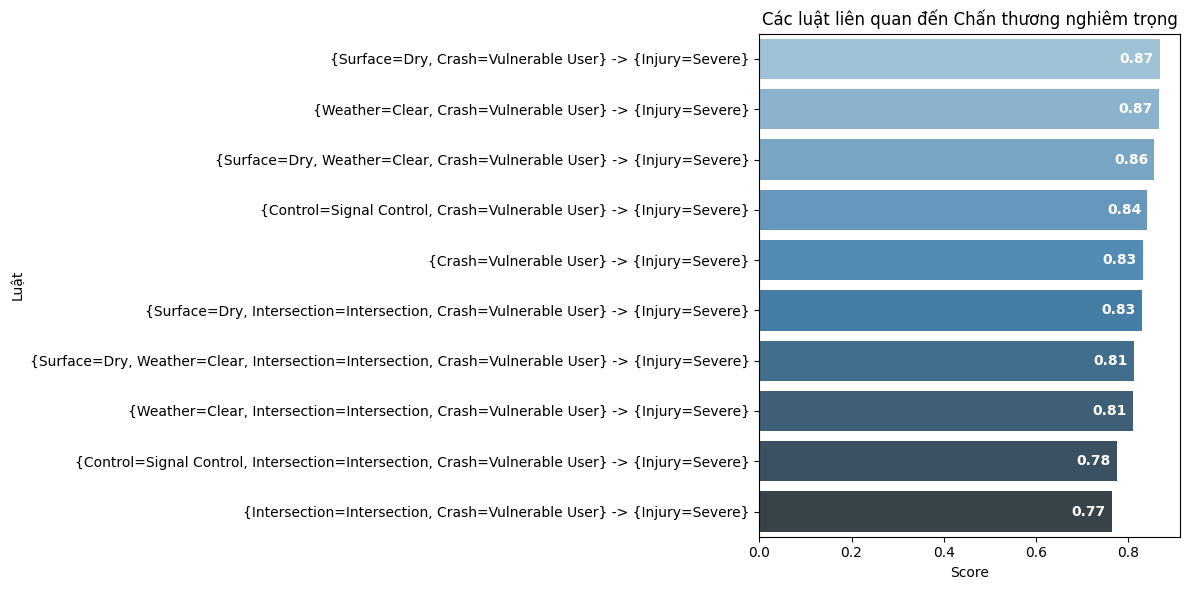

In [132]:
top_severe = top_severe.head(10)

top_severe['rule'] = top_severe.apply(format_rule_string, axis=1)

plt.figure(figsize=(12,6))
ax = sns.barplot(x='score', y='rule', data=top_severe, palette='Blues_d')
for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f}', 
                (p.get_width() - 0.05, p.get_y() + p.get_height()/2), 
                ha='center', va='center', color='white', fontweight='bold')
ax.set_title('Các luật liên quan đến Chấn thương nghiêm trọng')
ax.set_xlabel('Score')
ax.set_ylabel('Luật')
plt.tight_layout()
plt.show()

Nhận xét:
- Biểu đồ thể hiện các luật có điểm số cao nhất liên quan đến chấn thương nghiêm trọng cho thấy một đặc điểm rất rõ ràng: hầu hết các luật đều chứa yếu tố: Crash=Vulnerable User
- Điều này cho thấy khi tai nạn liên quan đến các đối tượng dễ bị tổn thương (như người đi bộ, xe đạp), khả năng dẫn đến chấn thương nghiêm trọng là rất cao.
- Ngoài ra, các yếu tố như Weather=Clear, Surface=Dry, Intersection=Intersection, hoặc Control=Signal Control thường xuyên xuất hiện trong các luật. Tuy nhiên, các yếu tố này không đóng vai trò nguyên nhân chính, mà chỉ là điều kiện bối cảnh đi kèm với loại va chạm.
- Một điểm đáng chú ý là các luật có thể mở rộng thêm nhiều yếu tố (ví dụ kết hợp cả Weather, Surface, Intersection) nhưng giá trị Score không thay đổi đáng kể. Điều này cho thấy:
    + Yếu tố cốt lõi quyết định vẫn là loại va chạm (Crash type)
    + Các yếu tố còn lại chỉ đóng vai trò bổ trợ

Summary Statistics - BT2 Severe Injury Patterns

In [120]:
print("SUMMARY STATISTICS - BT2 Severe Injury Patterns")

def print_severe_summary(rules_df):
    if len(rules_df) == 0:
        print("Không có luật")
        return
    
    print(f"Số luật liên quan tới Injury=Severe: {len(rules_df)}")
    print(f"Avg Confidence: {rules_df['confidence'].mean():.3f}")
    print(f"Avg Lift: {rules_df['lift'].mean():.3f}")
    print(f"Avg Support: {rules_df['support'].mean():.6f}")
    print(f"Max Lift: {rules_df['lift'].max():.3f}")
    print(f"Min Lift: {rules_df['lift'].min():.3f}")
    print(f"Tổng luật phát hiện (trước lọc): {len(rules_bt2)}")
    print(f"Phần trăm luật nghiêm trọng: {len(rules_df)/len(rules_bt2)*100:.5f}%")

print_severe_summary(rules_severe)

SUMMARY STATISTICS - BT2 Severe Injury Patterns
Số luật liên quan tới Injury=Severe: 24
Avg Confidence: 0.151
Avg Lift: 4.564
Avg Support: 0.006669
Max Lift: 4.765
Min Lift: 4.307
Tổng luật phát hiện (trước lọc): 2776195
Phần trăm luật nghiêm trọng: 0.00086%


Nhận xét:

Kết quả thống kê cho thấy chỉ có 24 luật liên quan đến chấn thương nghiêm trọng được phát hiện, chiếm khoảng 0.00086% trên tổng số hơn 2.7 triệu luật ban đầu. Điều này phản ánh rằng các trường hợp tai nạn nghiêm trọng là rất hiếm trong dữ liệu.

Các luật này có những đặc điểm đáng chú ý:
- Confidence trung bình thấp (0.151) -> xác suất xảy ra chấn thương nghiêm trọng nhìn chung không cao.
- Lift trung bình rất cao (4.564) -> khi các điều kiện trong luật xuất hiện, khả năng xảy ra chấn thương nghiêm trọng cao hơn nhiều so với ngẫu nhiên.
- Support rất thấp (0.006669) -> các pattern này hiếm, nhưng mang tính cảnh báo cao.
-> Sự kết hợp giữa confidence thấp nhưng lift cao cho thấy đây là các tình huống: hiếm nhưng nguy cơ cao

Đếm nhóm yếu tố trong luật nghiêm trọng

In [121]:
print("\nGroup Importance - Severe Rules")

env_c, beh_c, traf_c = 0, 0, 0

for _, rule in rules_severe.iterrows():
    items = list(rule['antecedents'])
    
    if any(any(col in item for col in env_cols) for item in items):
        env_c += 1
        
    if any(any(col in item for col in behavior_cols) for item in items):
        beh_c += 1
        
    if any(any(col in item for col in traffic_cols) for item in items):
        traf_c += 1

print(f"Nhóm Environment xuất hiện trong: {env_c} luật")
print(f"Nhóm Behavior xuất hiện trong: {beh_c} luật")
print(f"Nhóm Traffic xuất hiện trong: {traf_c} luật")


Group Importance - Severe Rules
Nhóm Environment xuất hiện trong: 18 luật
Nhóm Behavior xuất hiện trong: 24 luật
Nhóm Traffic xuất hiện trong: 12 luật


Độ mạnh từng nhóm

In [122]:
def group_stats_severe(rules):
    env_lift, beh_lift, traf_lift = [], [], []
    
    for _, rule in rules.iterrows():
        items = list(rule['antecedents'])
        
        if any(any(col in item for col in env_cols) for item in items):
            env_lift.append(rule['lift'])
            
        if any(any(col in item for col in behavior_cols) for item in items):
            beh_lift.append(rule['lift'])
            
        if any(any(col in item for col in traffic_cols) for item in items):
            traf_lift.append(rule['lift'])
    
    return (
        np.mean(env_lift) if env_lift else 0,
        np.mean(beh_lift) if beh_lift else 0,
        np.mean(traf_lift) if traf_lift else 0
    )

env_l, beh_l, traf_l = group_stats_severe(rules_severe)

print("Avg Lift - Environment:", env_l)
print("Avg Lift - Behavior:", beh_l)
print("Avg Lift - Traffic:", traf_l)

Avg Lift - Environment: 4.5416853407634825
Avg Lift - Behavior: 4.563965357640991
Avg Lift - Traffic: 4.590308008771239


Nhận xét ảnh hưởng của từng nhóm đến chấn thương nghiêm trọng dựa trên số lượng luật và lift trung bình:

Dựa trên số lượng luật và giá trị lift trung bình, có thể rút ra một số nhận định quan trọng về mức độ ảnh hưởng của từng nhóm yếu tố:
- Nhóm Hành vi (Behavior) đóng vai trò quan trọng nhất trong việc dẫn đến chấn thương nghiêm trọng. Nhóm này xuất hiện trong toàn bộ 24 luật, cho thấy mọi kịch bản tai nạn nghiêm trọng đều có sự liên quan đến hành vi của người tham gia giao thông (vi phạm luật, kiểu va chạm,…). Điều này khẳng định rằng hành vi con người là yếu tố cốt lõi quyết định mức độ nghiêm trọng của tai nạn.
- Nhóm Môi trường (Environment) xuất hiện trong 18/24 luật, cho thấy đây là yếu tố hỗ trợ quan trọng. Tuy không phải là nguyên nhân trực tiếp, nhưng các điều kiện như thời tiết, mặt đường hay ánh sáng góp phần làm gia tăng hoặc giảm nhẹ rủi ro khi tai nạn xảy ra.
- Nhóm Giao thông (Traffic) xuất hiện trong 12/24 luật, với giá trị lift trung bình cao nhất (~4.59).Điều này cho thấy khi các yếu tố hạ tầng (giao lộ, tín hiệu điều khiển,…) xuất hiện trong luật, thì mức độ liên kết với chấn thương nghiêm trọng là rất mạnh. Nói cách khác, các điểm giao thông phức tạp (như intersection) có xu hướng khuếch đại mức độ nguy hiểm của tai nạn.

Liên kết BT1 và BT2: Common Patterns vs Severity Risk

In [123]:
print("Phân tích liên kết: Common Patterns (BT1) → Severity Risk (BT2)")

# Lấy top features từ BT1 
bt1_features = set()
for _, rule in rules_clean.iterrows():
    for item in rule['antecedents']:
        bt1_features.add(item)

print(f"\n Features xuất hiện trong TOP patterns (BT1): {len(bt1_features)}")

# Kiểm tra features nào từ BT1 cũng xuất hiện trong severe patterns (BT2)
bt2_severe_features = set()
for _, rule in rules_severe.iterrows():
    for item in rule['antecedents']:
        bt2_severe_features.add(item)

overlap = bt1_features & bt2_severe_features
print(f"\n Features xuất hiện ở cả BT1 và BT2-Severe: {len(overlap)}")
if len(overlap) > 0:
    for feat in list(overlap)[:5]:
        print(f"  • {feat}")

print(f"\n Features phổ biến nhưng KHÔNG liên quan tới chấn thương nặng: {len(bt1_features - bt2_severe_features)}")
only_bt1 = list(bt1_features - bt2_severe_features)[:5]
for feat in only_bt1:
    print(f"  • {feat}")

print(f"\n Features hiếm nhưng có liên quan tới chấn thương nặng: {len(bt2_severe_features - bt1_features)}")
only_bt2 = list(bt2_severe_features - bt1_features)[:5]
for feat in only_bt2:
    print(f"  • {feat}")

# Insight
print("\n Insight:")
if len(bt1_features) > 0:
    overlap_ratio = len(overlap)/len(bt1_features)
    print(f"  - Phần trăm patterns phổ biến cũng là risk factor: {overlap_ratio*100:.1f}%")
    print(f"  - Điều này cho thấy: {'Phổ biến = Nguy hiểm' if overlap_ratio > 0.7 else 'Phổ biến ≠ Nguy hiểm (khác nhau)'}")

Phân tích liên kết: Common Patterns (BT1) → Severity Risk (BT2)

 Features xuất hiện trong TOP patterns (BT1): 18

 Features xuất hiện ở cả BT1 và BT2-Severe: 6
  • Control=Signal Control
  • Lighting=Daylight
  • Intersection=Intersection
  • Surface=Dry
  • Day=Weekday

 Features phổ biến nhưng KHÔNG liên quan tới chấn thương nặng: 12
  • Cause=Traffic Violation
  • Hour=Afternoon
  • Cause=Speed & Distance
  • Day=Weekend
  • Control=Stop/Yield Control

 Features hiếm nhưng có liên quan tới chấn thương nặng: 1
  • Crash=Vulnerable User

 Insight:
  - Phần trăm patterns phổ biến cũng là risk factor: 33.3%
  - Điều này cho thấy: Phổ biến ≠ Nguy hiểm (khác nhau)


Nhận xét:

Kết quả phân tích cho thấy mối liên hệ giữa các pattern phổ biến (BT1) và các yếu tố dẫn đến chấn thương nghiêm trọng (BT2) là không trùng khớp hoàn toàn.
- Trong tổng số 18 đặc trưng phổ biến được phát hiện từ BT1, chỉ có 6 đặc trưng (≈33.3%) cũng xuất hiện trong các luật liên quan đến chấn thương nghiêm trọng. Các yếu tố giao thoa này chủ yếu thuộc nhóm bối cảnh chung, bao gồm:
    + Điều kiện giao thông: Intersection, Signal Control
    + Điều kiện môi trường: Daylight, Surface=Dry
    + Thời gian: Weekday
    
    -> Điều này cho thấy một số yếu tố phổ biến vẫn có liên quan đến tai nạn nghiêm trọng, nhưng không phải là yếu tố quyết định.
- Ngược lại, có tới 12 đặc trưng phổ biến nhưng không liên quan đến chấn thương nặng, bao gồm:
    + Cause=Traffic Violation, Cause=Speed & Distance
    + Hour=Afternoon, Day=Weekend
    + Control=Stop/Yield Control
    
    -> Đây là một insight rất quan trọng:Những yếu tố gây tai nạn phổ biến chưa chắc dẫn đến hậu quả nghiêm trọng. Nói cách khác, tần suất xảy ra tai nạn không đồng nghĩa với mức độ nguy hiểm.
- Đáng chú ý, xuất hiện 1 yếu tố hiếm nhưng có liên quan mạnh đến chấn thương nghiêm trọng là: Crash=Vulnerable User (liên quan đến người đi bộ, xe đạp,…) -> Điều này chỉ ra rằng các tình huống ít gặp nhưng liên quan đến đối tượng dễ tổn thương lại có rủi ro rất cao về mức độ nghiêm trọng.

Feature Importance - Biến nào quan trọng nhất?

In [124]:
print("FEATURE IMPORTANCE - Biến nào xuất hiện nhiều nhất?")

def extract_features(rules_df, name):
    feature_count = {}
    feature_type = {}
    
    for _, rule in rules_df.iterrows():
        for item in rule['antecedents']:
            feature_count[item] = feature_count.get(item, 0) + 1
            feature_type[item] = feature_type.get(item, {'ant': 0, 'cons': 0})
            feature_type[item]['ant'] += 1
            
        for item in rule['consequents']:
            feature_count[item] = feature_count.get(item, 0) + 1
            feature_type[item] = feature_type.get(item, {'ant': 0, 'cons': 0})
            feature_type[item]['cons'] += 1
    
    sorted_features = sorted(feature_count.items(), key=lambda x: x[1], reverse=True)
    
    print(f"\n Top 10 features in {name}:")
    print(f"{'STT':<3} {'Feature':<35} {'Count':<8} {'Ant':<6} {'Cons':<6}")
    print("-" * 60)
    
    for idx, (feat, count) in enumerate(sorted_features[:10], 1):
        ant_count = feature_type[feat]['ant']
        cons_count = feature_type[feat]['cons']
        print(f"{idx:<3} {feat:<35} {count:<8} {ant_count:<6} {cons_count:<6}")
    
    return sorted_features, feature_count

# BT1 
print("\n Bài toán 1 (Common Patterns):")
bt1_sorted, _ = extract_features(rules_clean, "BT1")

# BT2
print("\n\n Bài toán 2 (Severe Injury Patterns):")
bt2_sorted, _ = extract_features(rules_severe, "BT2-Severe")

# So sánh
bt1_top10 = set([f for f, _ in bt1_sorted[:10]])
bt2_top10 = set([f for f, _ in bt2_sorted[:10]])

print(f"\n\n So sánh top 10 features:")
print(f"Xuất hiện ở cả BT1 & BT2: {len(bt1_top10 & bt2_top10)} features")
if len(bt1_top10 & bt2_top10) > 0:
    for feat in list(bt1_top10 & bt2_top10)[:5]:
        print(f"  • {feat}")

print(f"\n Insight:")
if len(bt1_sorted) > 0:
    print(f"  - BT1 yếu tố quan trọng nhất: {bt1_sorted[0][0]} (appears {bt1_sorted[0][1]}x)")
if len(bt2_sorted) > 0:
    print(f"  - BT2 yếu tố quan trọng nhất: {bt2_sorted[0][0]} (appears {bt2_sorted[0][1]}x)")

FEATURE IMPORTANCE - Biến nào xuất hiện nhiều nhất?

 Bài toán 1 (Common Patterns):

 Top 10 features in BT1:
STT Feature                             Count    Ant    Cons  
------------------------------------------------------------
1   Intersection=Intersection           317      168    149   
2   Cause=Traffic Violation             317      317    0     
3   Crash=Angle/Turning                 317      0      317   
4   Weather=Clear                       171      125    46    
5   Day=Weekday                         170      170    0     
6   Cause=Speed & Distance              166      166    0     
7   Crash=Rear-end                      166      0      166   
8   Control=Stop/Yield Control          161      161    0     
9   Trafficway=Intersection             153      153    0     
10  Surface=Dry                         138      120    18    


 Bài toán 2 (Severe Injury Patterns):

 Top 10 features in BT2-Severe:
STT Feature                             Count    Ant    Cons  


Nhận xét:

Phân tích tần suất xuất hiện của các đặc trưng trong các luật kết hợp cho thấy sự khác biệt rõ rệt giữa hai bài toán.

1. Đối với bài toán 1 – Common Patterns

Các đặc trưng xuất hiện nhiều nhất chủ yếu liên quan đến:
- Hạ tầng giao thông: Intersection=Intersection, Trafficway=Intersection, Control=Stop/Yield Control
- Hành vi và loại va chạm: Cause=Traffic Violation, Cause=Speed & Distance, Crash=Angle/Turning, Crash=Rear-end
- Điều kiện phổ biến: Weather=Clear, Surface=Dry, Day=Weekday

Đáng chú ý:
- Cause=Traffic Violation chỉ xuất hiện ở antecedents -> đóng vai trò nguyên nhân
- Crash=Angle/Turning và Crash=Rear-end chỉ xuất hiện ở consequents -> đóng vai trò kết quả trực tiếp

Điều này cho thấy: Tai nạn phổ biến chủ yếu xảy ra tại các giao lộ, bắt nguồn từ hành vi vi phạm, và dẫn đến các dạng va chạm điển hình.

2. Đối với bài toán 2 – Severe Injury Patterns

Các đặc trưng quan trọng nhất lại thay đổi đáng kể:
- Nổi bật nhất là: Crash=Vulnerable User (xuất hiện trong toàn bộ 24 luật)
- Các yếu tố đi kèm:
    + Intersection=Intersection
    + Weather=Clear, Surface=Dry
    + Lighting=Daylight, Day=Weekday

Insight: Mức độ nghiêm trọng không phụ thuộc nhiều vào hành vi phổ biến, mà phụ thuộc mạnh vào loại va chạm, đặc biệt là khi liên quan đến đối tượng dễ tổn thương (người đi bộ, xe đạp, …).

3. So sánh giữa hai bài toán

- Chỉ có 4 đặc trưng chung giữa top 10 của hai bài toán:
    + Intersection=Intersection
    + Weather=Clear
    + Surface=Dry
    + Day=Weekday

    -> Đây đều là các yếu tố bối cảnh chung, không mang tính quyết định.

- Sự khác biệt cốt lõi:
    + BT1 (phổ biến): bị chi phối bởi hành vi và tần suất
    + BT2 (nghiêm trọng): bị chi phối bởi loại va chạm và đối tượng

Insight: Không phải yếu tố gây tai nạn nhiều nhất là nguy hiểm nhất, yếu tố quyết định mức độ nghiêm trọng lại là loại va chạm và đối tượng bị ảnh hưởng.